In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import multiprocessing
from sklearn.cluster import MeanShift
import random
from sklearn.linear_model import LinearRegression

from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
from y_n import y_n
from upsilon_n import upsilon_n

In [4]:
def upsilons(N, T):
    return {n: upsilon_n(n, T) for n in N}

In [5]:
np.random.seed(84)
random.seed(84)

In [6]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [7]:
pd.options.display.max_seq_items = 2000

In [8]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

kinetic_data['cluster'] = clustering.labels_

cluster_set = list(set(kinetic_data.cluster))

index_clusters = kinetic_data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [9]:
kinetic_data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [10]:
kinetic_data.groupby(['cluster'])['T_R_C'].std()

cluster
0    0.000000
1    0.478714
2    0.000000
3    0.000000
4    0.000000
5    0.522233
6    0.527046
Name: T_R_C, dtype: float64

In [11]:
kinetic_data['cluster'].isin(val_clusters).sum() / len(kinetic_data)

np.float64(0.26262626262626265)

In [12]:
Fj_out = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11',
       'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
    'F_C17', 'F_C18', 'F_C19',
       'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 
        'F_C26', 'F_C27',
       'F_C28', 'F_C29', 'F_C30',
    # 'F_C31', 'F_C32', 'F_C33', 'F_C34', 'F_C35',
    #    'F_C36', 
    'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14', 'F_Olef_C15',
       # 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
]]

In [13]:
Fj_out_HCs = Fj_out.drop(columns=['F_H2_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s', 'F_H2O_s_mol_s'])

In [14]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       # 'F_C31': 31, 'F_C32': 32,
       # 'F_C33': 33, 'F_C34': 34, 'F_C35': 35, 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       # 'F_Olef_C16': 16, 'F_Olef_C17': 17, 'F_Olef_C18': 18, 
}

In [15]:
all_Ns = list(set(list(Ns_parafins.values()) + list(Ns_olefins.values())))

In [16]:
rates_Ns_parafins = {
    'r_CH4_s_mol_s': 1, 'r_C2H6_s_mol_s': 2, 'r_C3H8_s_mol_s': 3,
       'r_C9': 9, 'r_C10': 10, 'r_C11': 11, 'r_C12': 12, 'r_C13': 13, 'r_C14': 14, 'r_C15': 15, 'r_C16': 16,
       'r_C17': 17, 'r_C18': 18, 'r_C19': 19, 'r_C20': 20, 'r_C21': 21, 'r_C22': 22, 'r_C23': 23, 'r_C24': 24,
       'r_C25': 25,
       'r_C26': 26, 'r_C27': 27, 'r_C28': 28, 'r_C29': 29, 'r_C30': 30,
       # 'r_C31': 31, 'r_C32': 32,
       # 'r_C33': 33, 'r_C34': 34, 'r_C35': 35, 'r_C36': 36,
}
rates_Ns_olefins = {
    'r_C2H4_s_mol_s': 2,
       'r_Olef_C9': 9, 'r_Olef_C10': 10,
       'r_Olef_C11': 11, 'r_Olef_C12': 12, 'r_Olef_C13': 13, 'r_Olef_C14': 14, 'r_Olef_C15': 15,
       # 'r_Olef_C16': 16, 'r_Olef_C17': 17, 'r_Olef_C18': 18, 
}

In [17]:
MM_parafins = {key: (n*12 + 2*n + 2) for key, n in Ns_parafins.items()}
MM_olefins = {key: (n*12 + 2*n) for key, n in Ns_olefins.items()}

In [18]:
Fj_out_HCs_parafins = Fj_out_HCs[Ns_parafins.keys()]
Fj_out_HCs_olefins = Fj_out_HCs[Ns_olefins.keys()]

In [19]:
m_out_parafins = Fj_out_HCs_parafins.mul(MM_parafins, axis = 'columns')
m_out_olefins = Fj_out_HCs_olefins.mul(MM_olefins, axis = 'columns')

In [20]:
rates_exp_parafins = Fj_out_HCs_parafins.div(kinetic_data.m_cat_g, axis='rows')
rates_exp_olefins = Fj_out_HCs_olefins.div(kinetic_data.m_cat_g, axis='rows')
rates_exp_parafins.columns = rates_exp_parafins.columns.str.replace('^F_', 'r_', regex=True)
rates_exp_olefins.columns = rates_exp_olefins.columns.str.replace('^F_', 'r_', regex=True)

rates_exp_CO2 = kinetic_data.F_CO2_s_mol_s / kinetic_data.m_cat_g
rates_exp_H2 = (kinetic_data.F_H2_s_mol_s - kinetic_data.F_H2_e_mol_s) / kinetic_data.m_cat_g
rates_exp_CO = (kinetic_data.F_CO_s_mol_s - kinetic_data.F_CO_e_mol_s) / kinetic_data.m_cat_g
rates_exp_H2O = kinetic_data.F_H2O_s_mol_s / kinetic_data.m_cat_g

In [21]:
rates_exp_HCs = Fj_out_HCs.sum(axis = 'columns').div(kinetic_data.m_cat_g, axis='rows')

In [22]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [23]:
len(kinetic_data) == len(kinetic_data.loc[loc_validation]) + len(kinetic_data.loc[loc_training])

False

In [24]:
F_CO_in = kinetic_data.F_CO_e_mol_s
F_CO_out = kinetic_data.F_CO_s_mol_s

F_H2_in = kinetic_data.F_H2_e_mol_s
F_H2_out = kinetic_data.F_H2_s_mol_s

y_H2_in = F_H2_in / (F_H2_in + F_CO_in)
y_CO_in = F_CO_in / (F_H2_in + F_CO_in)

y_H2_out = Fj_out['F_H2_s_mol_s'] / Fj_out.sum(axis=1)
y_CO_out = Fj_out['F_CO_s_mol_s'] / Fj_out.sum(axis=1)
y_CO2_out = Fj_out['F_CO2_s_mol_s'] / Fj_out.sum(axis=1)
y_H2O_out = Fj_out['F_H2O_s_mol_s'] / Fj_out.sum(axis=1)

y_H2_mean = ( y_H2_in + y_H2_out ) / 2
y_CO_mean = ( y_CO_in + y_CO_out ) / 2

kinetic_data['P_H2'] = (kinetic_data.P_abs_Pa * y_H2_out).astype('float')
kinetic_data['P_CO'] = (kinetic_data.P_abs_Pa * y_CO_out).astype('float')
kinetic_data['P_CO2'] = (kinetic_data.P_abs_Pa * y_CO2_out).astype('float')
kinetic_data['P_H2O'] = (kinetic_data.P_abs_Pa * y_H2O_out).astype('float')

In [25]:
def yn_upsilon_n(upsilons, T, index):
    return pd.DataFrame({n: y_n(n, T) * upsilons[n] for n in rates_Ns_parafins.values()},
                       index = index)

In [26]:
def yn_1_minus_upsilon_n(upsilons, T, index):
    return pd.DataFrame({n: y_n(n, T) * (1 - upsilons[n]) for n in rates_Ns_olefins.values()},
                       index = index)

In [27]:
def model_rates_parafins(data, rate_fcn, params):
    Ns = rates_Ns_parafins.values()
    
    rates = yn_upsilon_n( 
                         upsilons(Ns, data.T_R_K.values),
                         data.T_R_K.values,
                         data.index).mul(
                                        rate_fcn(*params, 
                                        data.T_R_K.values, 
                                        data.P_CO.values, 
                                        data.P_H2.values), axis='index')
    
    rates = rates.rename(columns = {value: key for key, value in rates_Ns_parafins.items()})
    
    return rates

In [28]:
def model_rates_olefins(data, rate_fcn, params):
    Ns = rates_Ns_olefins.values()
    
    rates = yn_1_minus_upsilon_n( 
                                 upsilons(Ns, data.T_R_K.values),
                                 data.T_R_K.values,
                                 data.index).mul(
                                                rate_fcn(*params, 
                                                data.T_R_K.values,
                                                data.P_CO.values,
                                                data.P_H2.values
                                                        ), axis='index')
    
    rates = rates.rename(columns = {value: key for key, value in rates_Ns_olefins.items()})
    
    return rates

In [29]:
def model_Fout(rates, W):
    Fout_model = rates.mul(W, axis = 'index')
    Fout_model.columns = Fout_model.columns.str.replace('^r_', 'F_', regex=True)
    return Fout_model

In [30]:
def model_rates_CO(rates_model_parafins, rates_model_olefins):
    rates_model_CO  = rates_model_parafins.mul(rates_Ns_parafins, axis = 'columns').sum(axis = 'columns')
    rates_model_CO += rates_model_olefins.mul(rates_Ns_olefins, axis = 'columns').sum(axis = 'columns')
    return - rates_model_CO

In [31]:
def model_rates_H2(rates_model_parafins, rates_model_olefins):
    stoic_H2_parafins = {key: (value * 2 + 1) for key, value in rates_Ns_parafins.items()}
    stoic_H2_olefins = {key: (value * 2) for key, value in rates_Ns_olefins.items()}
    
    rates_model_H2  = rates_model_parafins.mul(stoic_H2_parafins, axis = 'columns').sum(axis = 'columns')
    rates_model_H2 += rates_model_olefins.mul(stoic_H2_olefins, axis = 'columns').sum(axis = 'columns')
    return - rates_model_H2

In [32]:
params_WGS = np.load('params_WGS.npy')

def model_rates_CO2(data):
    K_WGS = 1.45e-2 * np.exp( 4.62e3 / data.T_R_K )
    
    A_WGS = params_WGS[0]
    E_WGS = params_WGS[1]
    a = params_WGS[2]
    b = params_WGS[3]

    eta = data.P_CO2 * data.P_H2 / ( K_WGS * data.P_H2O * data.P_CO )
    
    k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * data.T_R_K ) )
    
    rate_WGS = ( k_WGS * data.P_CO**a * data.P_H2O**b ) * ( 1 - eta )
    
    return rate_WGS

In [33]:
def residuals(params, data, rate_fcn):

    rates_model_CO2  = model_rates_CO2(data)
    rates_model_parafins = model_rates_parafins(data, rate_fcn, params)
    rates_model_olefins  = model_rates_olefins( data, rate_fcn, params)
    rates_model_CO  = model_rates_CO(rates_model_parafins, rates_model_olefins) - rates_model_CO2
    rates_model_H2  = model_rates_H2(rates_model_parafins, rates_model_olefins) + rates_model_CO2
    rates_model_H2O = - model_rates_CO(rates_model_parafins, rates_model_olefins) - rates_model_CO2
    
    res_parafins = (rates_exp_parafins - rates_model_parafins)
    res_olefins  = (rates_exp_olefins - rates_model_olefins)
    res_CO = (rates_exp_CO - rates_model_CO)
    res_H2 = (rates_exp_H2 - rates_model_H2)
    res_CO2 = (rates_exp_CO2 - rates_model_CO2)
    res_H2O = (rates_exp_H2O - rates_model_H2O)

    res_parafins = res_parafins.dropna()
    res_olefins = res_olefins.dropna()
    res_CO = res_CO.dropna()
    res_H2 = res_H2.dropna()
    res_CO2 = res_CO2.dropna()
    res_H2O = res_H2O.dropna()

    res = np.concatenate((
        res_parafins.values.flatten(),
        res_olefins.values.flatten(),
        res_CO.values.flatten(),
        res_H2.values.flatten(),
        res_CO2.values.flatten(),
        res_H2O.values.flatten()
    ))

    return res

In [34]:
def neg_loglik(params, data, rate_fcn):
    res = residuals(params, data, rate_fcn)
    return -norm.logpdf(res, res.mean(), res.std()).sum()

In [35]:
def objective_fcn(params, data, rate_fcn):
    res = residuals(params, data, rate_fcn)
    
    sum_diff_sqr = ( res ** 2 ).sum()
    
    # print(params)
    # print(sum_diff_sqr)
    # clear_output(wait = True)
    
    return sum_diff_sqr

In [36]:
def fit_function(train_data, rate_fcn, p0, bnds, model_name, max_fev, method):
    sol = minimize(objective_fcn, p0,
             method=method,
             bounds=bnds, 
             args = (train_data, rate_fcn),
             options = {'maxfev': max_fev*len(p0)},
             )
    return sol

In [37]:
max_fev = 2
A_HCs_0 = 1
results_minimization = pd.DataFrame()

In [38]:
def rate_HCs_PowerLaw(A_HCs, E_HCs, a, b, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    rate = k_HCs * P_H2 ** a * P_CO ** b
    return rate

p0_PowerLaw = [A_HCs_0, 1e5, 1, 1]
p0_PowerLaw = [ 9.51641676e-02,  2.41672178e+04, -6.91509613e-01,  2.09762874e-01]

PowerLaw_bnds = ( (0, None), (0, None), (None, None), (None, None) )

print('Solving PowerLaw...')

sol_PowerLaw = fit_function(kinetic_data.loc[loc_training], rate_HCs_PowerLaw, p0_PowerLaw, 
                         PowerLaw_bnds, 'PowerLaw', max_fev, 'Nelder-Mead')

PowerLaw_param_dict =  {'A_HCs': sol_PowerLaw.x[0]*1000,
                       'E_HCs': sol_PowerLaw.x[1],
                       'a': sol_PowerLaw.x[2],
                       'b': sol_PowerLaw.x[3],
                       }

K = len(sol_PowerLaw.x)
aic_train = 2*K + 2*neg_loglik(sol_PowerLaw.x, kinetic_data[loc_training], rate_HCs_PowerLaw)
aic_val = 2*K + 2*neg_loglik(sol_PowerLaw.x, kinetic_data[loc_validation], rate_HCs_PowerLaw)

results_minimization.loc['PowerLaw', 'fun'] = sol_PowerLaw.fun
results_minimization.loc['PowerLaw', 'nfev'] = sol_PowerLaw.nfev
results_minimization.loc['PowerLaw', 'success'] = sol_PowerLaw.success
results_minimization.loc['PowerLaw', 'message'] = sol_PowerLaw.message
results_minimization.loc['PowerLaw', 'aic_train'] = aic_train
results_minimization.loc['PowerLaw', 'aic_val'] = aic_val

Solving PowerLaw...


In [39]:
def rate_HCs_Yates(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_H2 * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Yates = [1, 5e4, A_HCs_0, 1e5]
p0_Yates = [1.83961020e-03, 2.04240780e+04, 1.36601911e+02, 1.79827465e+05]

Yates_bnds = ( (0, None), (0, None), (0, None), (0, None) )

print('Solving Yates...')

sol_Yates = fit_function(kinetic_data.loc[loc_training], rate_HCs_Yates, p0_Yates, 
                         Yates_bnds, 'Yates', max_fev, 'Nelder-Mead')

Yates_param_dict =    {'k_ads': sol_Yates.x[0],
                       'H_ads': sol_Yates.x[1],
                       'A_HCs': sol_Yates.x[2]*1000,
                       'E_HCs': sol_Yates.x[3],
                       }

K = len(sol_Yates.x)
aic_train = 2*K + 2*neg_loglik(sol_Yates.x, kinetic_data[loc_training], rate_HCs_Yates)
aic_val = 2*K + 2*neg_loglik(sol_Yates.x, kinetic_data[loc_validation], rate_HCs_Yates)

results_minimization.loc['Yates', 'fun'] = sol_Yates.fun
results_minimization.loc['Yates', 'nfev'] = sol_Yates.nfev
results_minimization.loc['Yates', 'success'] = sol_Yates.success
results_minimization.loc['Yates', 'message'] = sol_Yates.message
results_minimization.loc['Yates', 'aic_train'] = aic_train
results_minimization.loc['Yates', 'aic_val'] = aic_val

Solving Yates...


In [40]:
def rate_HCs_Botes(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_H2 ** 0.75 * P_CO ** 0.5 / ( ( 1 + K_CO * P_CO ** 0.5 ) ** 2 )
    return rate

p0_Botes = [1, 5e4, A_HCs_0, 1e5]

p0_Botes = [4.06884862e-02, 8.91771212e-07, 1.83999665e+04, 1.48059209e+05]

Botes_bnds = ( (0, None), (0, None), (0, None), (0, None) )

print('Solving Botes...')

sol_Botes = fit_function(kinetic_data.loc[loc_training], rate_HCs_Botes, p0_Botes, 
                         Botes_bnds, 'Botes', max_fev, 'Nelder-Mead')

Botes_param_dict =    {'k_ads': sol_Botes.x[0],
                       'H_ads': sol_Botes.x[1],
                       'A_HCs': sol_Botes.x[2]*1000,
                       'E_HCs': sol_Botes.x[3],
                       }

K = len(sol_Botes.x)
aic_train = 2*K + 2*neg_loglik(sol_Botes.x, kinetic_data[loc_training], rate_HCs_Botes)
aic_val = 2*K + 2*neg_loglik(sol_Botes.x, kinetic_data[loc_validation], rate_HCs_Botes)

results_minimization.loc['Botes', 'fun'] = sol_Botes.fun
results_minimization.loc['Botes', 'nfev'] = sol_Botes.nfev
results_minimization.loc['Botes', 'success'] = sol_Botes.success
results_minimization.loc['Botes', 'message'] = sol_Botes.message
results_minimization.loc['Botes', 'aic_train'] = aic_train
results_minimization.loc['Botes', 'aic_val'] = aic_val

Solving Botes...


In [41]:
def rate_HCs_Ojeda(k_ads, H_ads, A_HCs_1, E_HCs_1, A_HCs_2, E_HCs_2, T, P_CO, P_H2):
    k_HCs_1 = A_HCs_1 * np.exp ( - E_HCs_1 / ( 8.314 * T ) )
    k_HCs_2 = A_HCs_2 * np.exp ( - E_HCs_2 / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = ( k_HCs_1 * P_H2 + k_HCs_2 ) * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Ojeda = [1, 5e4, A_HCs_0, 1e5, A_HCs_0, 1e5]

p0_Ojeda = [8.42529950e-03, 3.43658718e+04, 1.21423307e+00, 2.03597298e+05,
       3.94267841e+00, 1.17018279e+05]

Ojeda_bnds = ( (0, None), (0, None), (0, None), (0, None), (0, None), (0, None) )

print('Solving Ojeda...')

sol_Ojeda = fit_function(kinetic_data.loc[loc_training], rate_HCs_Ojeda, p0_Ojeda,
                         Ojeda_bnds, 'Ojeda', max_fev, 'Nelder-Mead')

Ojeda_param_dict =    {'k_ads': sol_Ojeda.x[0],
                       'H_ads': sol_Ojeda.x[1],
                       'A_HCs_1': sol_Ojeda.x[2]*1000,
                       'E_HCs_1': sol_Ojeda.x[3],
                       'A_HCs_2': sol_Ojeda.x[4]*1000,
                       'E_HCs_2': sol_Ojeda.x[5],
                       }

K = len(sol_Ojeda.x)
aic_train = 2*K + 2*neg_loglik(sol_Ojeda.x, kinetic_data[loc_training], rate_HCs_Ojeda)
aic_val = 2*K + 2*neg_loglik(sol_Ojeda.x, kinetic_data[loc_validation], rate_HCs_Ojeda)

results_minimization.loc['Ojeda', 'fun'] = sol_Ojeda.fun
results_minimization.loc['Ojeda', 'nfev'] = sol_Ojeda.nfev
results_minimization.loc['Ojeda', 'success'] = sol_Ojeda.success
results_minimization.loc['Ojeda', 'message'] = sol_Ojeda.message
results_minimization.loc['Ojeda', 'aic_train'] = aic_train
results_minimization.loc['Ojeda', 'aic_val'] = aic_val

Solving Ojeda...


In [42]:
def rate_HCs_Mousavi(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_H2 ** 0.75 * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Mousavi = [1, 5e4, A_HCs_0, 1e5]

p0_Mousavi = [3.15314291e-05, 6.23346961e+03, 7.45002850e+00, 1.58380603e+05]

Mousavi_bnds = ( (0, None), (0, None), (0, None), (0, None) )

print('Solving Mousavi...')

sol_Mousavi = fit_function(kinetic_data.loc[loc_training], rate_HCs_Mousavi, p0_Mousavi,
                         Mousavi_bnds, 'Mousavi', max_fev, 'Nelder-Mead')

Mousavi_param_dict =    {'k_ads': sol_Mousavi.x[0],
                       'H_ads': sol_Mousavi.x[1],
                       'A_HCs': sol_Mousavi.x[2]*1000,
                       'E_HCs': sol_Mousavi.x[3],
                       }

K = len(sol_Mousavi.x)
aic_train = 2*K + 2*neg_loglik(sol_Mousavi.x, kinetic_data[loc_training], rate_HCs_Mousavi)
aic_val = 2*K + 2*neg_loglik(sol_Mousavi.x, kinetic_data[loc_validation], rate_HCs_Mousavi)

results_minimization.loc['Mousavi', 'fun'] = sol_Mousavi.fun
results_minimization.loc['Mousavi', 'nfev'] = sol_Mousavi.nfev
results_minimization.loc['Mousavi', 'success'] = sol_Mousavi.success
results_minimization.loc['Mousavi', 'message'] = sol_Mousavi.message
results_minimization.loc['Mousavi', 'aic_train'] = aic_train
results_minimization.loc['Mousavi', 'aic_val'] = aic_val

Solving Mousavi...


In [43]:
def rate_HCs_PowerLaw2(k_ads, H_ads, A_HCs, E_HCs, a, b, c, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_H2 ** a * P_CO ** b / ( ( 1 + K_CO * P_CO ** c ) ** 2 )
    return rate

p0_PowerLaw2 = [1, 5e4, A_HCs_0, 1e5, 1, 1, 1]

p0_PowerLaw2 = [2.53927053e-01, 4.62947691e-05, 1.17166444e+00, 6.72057461e+04,
       2.36217280e-10, 2.46990773e+00, 1.30314910e+00]

PowerLaw2_bnds = ( (0, None), (0, None), (0, None), (0, None),
                 (0, None), (0, None), (0, None),
               )

print('Solving PowerLaw2...')

sol_PowerLaw2 = fit_function(kinetic_data.loc[loc_training], rate_HCs_PowerLaw2, p0_PowerLaw2, 
                         PowerLaw2_bnds, 'PowerLaw2', max_fev, 'Nelder-Mead')

PowerLaw2_param_dict =    {'k_ads': sol_PowerLaw2.x[0],
                       'H_ads': sol_PowerLaw2.x[1],
                       'A_HCs': sol_PowerLaw2.x[2]*1000,
                       'E_HCs': sol_PowerLaw2.x[3],
                       'a': sol_PowerLaw2.x[4],
                       'b': sol_PowerLaw2.x[5],
                       'c': sol_PowerLaw2.x[6],
                       }

K = len(sol_PowerLaw2.x)
aic_train = 2*K + 2*neg_loglik(sol_PowerLaw2.x, kinetic_data[loc_training], rate_HCs_PowerLaw2)
aic_val = 2*K + 2*neg_loglik(sol_PowerLaw2.x, kinetic_data[loc_validation], rate_HCs_PowerLaw2)

results_minimization.loc['PowerLaw2', 'fun'] = sol_PowerLaw2.fun
results_minimization.loc['PowerLaw2', 'nfev'] = sol_PowerLaw2.nfev
results_minimization.loc['PowerLaw2', 'success'] = sol_PowerLaw2.success
results_minimization.loc['PowerLaw2', 'message'] = sol_PowerLaw2.message
results_minimization.loc['PowerLaw2', 'aic_train'] = aic_train
results_minimization.loc['PowerLaw2', 'aic_val'] = aic_val

Solving PowerLaw2...


In [44]:
results_minimization.sort_values('aic_val')

,fun,nfev,success,message,aic_train,aic_val
PowerLaw,1.523807e-10,8.0,False,Maximum number of function evaluations has bee...,-60983.419355,-25511.491417
PowerLaw2,1.944907e-10,14.0,False,Maximum number of function evaluations has bee...,-60432.713718,-25461.035976
Ojeda,2.046955e-10,12.0,False,Maximum number of function evaluations has bee...,-60322.407673,-25301.427967
Mousavi,3.661594e-10,8.0,False,Maximum number of function evaluations has bee...,-59039.910367,-25235.389184
Botes,3.687812e-10,8.0,False,Maximum number of function evaluations has bee...,-59027.038111,-25157.019952
Yates,4.715781e-10,8.0,False,Maximum number of function evaluations has bee...,-58478.487405,-25063.272846


In [45]:
params_dict = {
    'PowerLaw'  : PowerLaw_param_dict,
    'Yates'     : Yates_param_dict,
    'Botes'     : Botes_param_dict,
    'Ojeda'     : Ojeda_param_dict,
    'Mousavi'   : Mousavi_param_dict,
    'PowerLaw2' : PowerLaw2_param_dict,
              }

In [46]:
rates_exp = pd.concat((rates_exp_parafins, rates_exp_olefins), axis = 'columns')
rates_exp['-r_CO'] = - rates_exp_CO
rates_exp['-r_H2'] = - rates_exp_H2
rates_exp['r_CO2'] = rates_exp_CO2
rates_exp['index'] = kinetic_data.index

In [47]:
def rates_model(data, rate_fcn, params):
    
    rates_model_CO2  = model_rates_CO2(data)
    rates_model_parafins = model_rates_parafins(data, rate_fcn, params)
    rates_model_olefins  = model_rates_olefins( data, rate_fcn, params)
    rates_model_CO  = model_rates_CO(rates_model_parafins, rates_model_olefins) - rates_model_CO2
    rates_model_H2  = model_rates_H2(rates_model_parafins, rates_model_olefins) + rates_model_CO2
    rates_model_H2O = - model_rates_CO(rates_model_parafins, rates_model_olefins) - rates_model_CO2
    
    rates_model = pd.concat((rates_model_parafins, rates_model_olefins), axis = 'columns')
    rates_model['-r_CO'] = - rates_model_CO
    rates_model['-r_H2'] = - rates_model_H2
    rates_model['r_CO2'] = rates_model_CO2
    rates_model['r_H2O'] = rates_model_H2O
    
    rates_model = rates_model[rates_exp.drop('index', axis = 'columns').columns]
    return rates_model

In [48]:
leg_dict = {
    'r_CH4_s_mol_s': 'parafins',
    'r_C2H6_s_mol_s': 'parafins', 
    'r_C3H8_s_mol_s': 'parafins', 
    'r_C9': 'parafins',
    'r_C10': 'parafins',
    'r_C11': 'parafins', 
    'r_C12': 'parafins', 
    'r_C13': 'parafins', 
    'r_C14': 'parafins', 
    'r_C15': 'parafins', 
    'r_C16': 'parafins', 
    'r_C17': 'parafins', 
    'r_C18': 'parafins',
    'r_C19': 'parafins', 
    'r_C20': 'parafins', 
    'r_C21': 'parafins', 
    'r_C22': 'parafins', 
    'r_C23': 'parafins', 
    'r_C24': 'parafins', 
    'r_C25': 'parafins', 
    'r_C26': 'parafins',
    'r_C27': 'parafins', 
    'r_C28': 'parafins', 
    'r_C29': 'parafins', 
    'r_C30': 'parafins', 
    'r_C2H4_s_mol_s': 'olefins', 
    'r_Olef_C9': 'olefins',
    'r_Olef_C10': 'olefins', 
    'r_Olef_C11': 'olefins', 
    'r_Olef_C12': 'olefins', 
    'r_Olef_C13': 'olefins', 
    'r_Olef_C14': 'olefins',
    'r_Olef_C15': 'olefins', 
    '-r_CO': r'CO / $\mathrm{H_2 O}$', 
    '-r_H2': r'$\mathrm{H_2}$',
    'r_CO2': r'$\mathrm{CO_2}$',
    'r_H2O': r'$\mathrm{H_2O}$',
}

In [49]:
rates_PowerLaw = rates_model(kinetic_data, rate_HCs_PowerLaw, sol_PowerLaw.x)
rates_Yates = rates_model(kinetic_data, rate_HCs_Yates, sol_Yates.x)
rates_Botes = rates_model(kinetic_data, rate_HCs_Botes, sol_Botes.x)
rates_Ojeda = rates_model(kinetic_data, rate_HCs_Ojeda, sol_Ojeda.x)
rates_Mousavi = rates_model(kinetic_data, rate_HCs_Mousavi, sol_Mousavi.x)
rates_PowerLaw2 = rates_model(kinetic_data, rate_HCs_PowerLaw2, sol_PowerLaw2.x)

In [50]:
rates = rates_exp.melt(var_name = 'component', value_name = 'rates_exp', id_vars = 'index')

rates['rates_PowerLaw'] = rates_PowerLaw.melt()['value']
rates['rates_Yates'] = rates_Yates.melt()['value']
rates['rates_Botes'] = rates_Botes.melt()['value']
rates['rates_Ojeda'] = rates_Ojeda.melt()['value']
rates['rates_Mousavi'] = rates_Mousavi.melt()['value']
rates['rates_PowerLaw2'] = rates_PowerLaw2.melt()['value']

rates['legend'] = rates['component'].map(leg_dict)
rates['training'] = rates['index'].isin(idx_training)

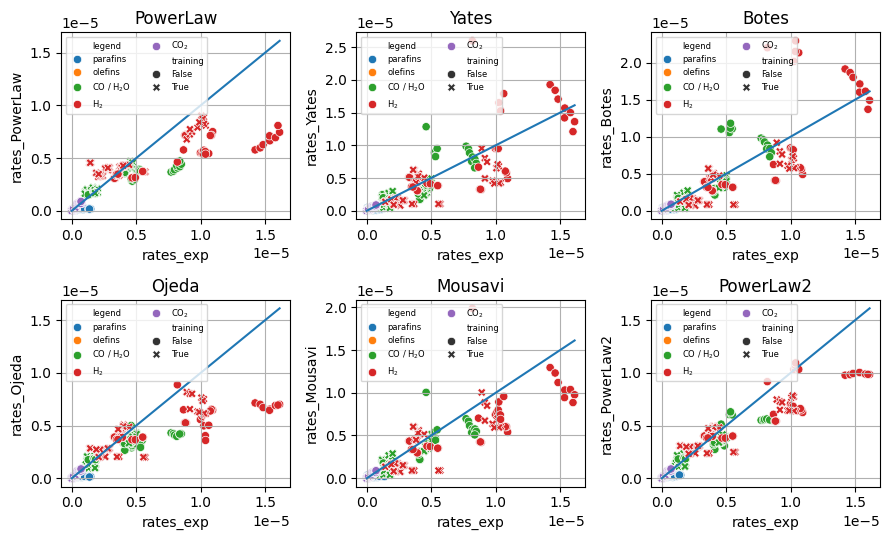

In [51]:
fig, axs = plt.subplots(2, 3, figsize = (9, 5.5))
flat_axs = axs.flatten()

max_xy = rates.rates_exp.max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = rates, x = 'rates_exp', y = f'rates_{model}',
                    ax=flat_axs[i],
                    hue = 'legend', style = 'training',
                   )
    flat_axs[i].set_title(model)
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend(fontsize = 6, ncols = 2)
plt.tight_layout()
fig_name = 'rates_parity.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

In [52]:
def solve_bootstrap(model_name, rate_fcn, p0, bnds, bootstrap_sample, bootstrap_results, i, run):
    print(f'Bootstrap iteration {i} for {model_name}')
    clear_output(wait=True)
    sol = fit_function(bootstrap_sample, rate_fcn, p0, None, model_name, len(p0)*400, 'Nelder-Mead')
    # MAE = calc_MAE(model_name)

    bootstrap_results['model'].append(model_name)
    bootstrap_results['iteration'].append(i)
    bootstrap_results['run'].append(run)
    # bootstrap_results['mean_absolute_error'].append(MAE)
    bootstrap_results['params'].append(sol.x)
    bootstrap_results['success'].append(sol.success)
    bootstrap_results['nfev'].append(sol.nfev)
    bootstrap_results['message'].append(sol.message)

    return bootstrap_results

In [53]:
# bootstrapping
def run_bootstrap(args):
    boot_iterations, run = args
    bootstrap_results = {'model': [], 'iteration': [], 'run': [],
                         # 'mean_absolute_error': [], 
                         'params': [],
                     'success': [], 'nfev': [], 'message': [],
                    }
    for i in range(boot_iterations):
        # generate a bootstrap sample of the same len as kinetic data from the trainning data
        sample_size = int(len(kinetic_data)/1)
        np.random.seed(None)
        bootstrap_sample = kinetic_data.loc[loc_training].sample(n = sample_size, replace = True)
    
        bootstrap_results = solve_bootstrap('PowerLaw', rate_HCs_PowerLaw, sol_PowerLaw.x, 
                                            PowerLaw_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)
    
        bootstrap_results = solve_bootstrap('Yates', rate_HCs_Yates, sol_Yates.x,
                                            Yates_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)
    
        bootstrap_results = solve_bootstrap('Botes', rate_HCs_Botes, sol_Botes.x,
                                            Botes_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('Ojeda', rate_HCs_Ojeda, sol_Ojeda.x, 
                                            Ojeda_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('PowerLaw2', rate_HCs_PowerLaw2, sol_PowerLaw2.x, 
                                            PowerLaw2_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('Mousavi', rate_HCs_Mousavi, sol_Mousavi.x, 
                                            Mousavi_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)

    bootstrap_results = pd.DataFrame(bootstrap_results)

    return bootstrap_results

# if __name__ == '__main__':
# --- Parallel Execution ---

boot_iterations_per_run = 42

all_runs_input = [(boot_iterations_per_run, run) for run in range(24)]

# Get the number of CPU cores available for parallel processing
num_processes = multiprocessing.cpu_count()
if len(all_runs_input) < num_processes:
    num_processes = len(all_runs_input)

print('Bootstrapping...')
print(f"Using {num_processes} cores for parallel processing.")

# Create a Pool of worker processes
with multiprocessing.Pool(processes=num_processes) as pool:
    # pool.map() applies the run_single_bootstrap function to every item
    # in the all_runs_input list and waits for results.
    results = pool.map(run_bootstrap, all_runs_input)

bootstrap_results = pd.concat([result for result in results])

bootstrap_results.to_pickle('bootstrap_results.pkl')

In [54]:
bootstrap_results = pd.read_pickle('bootstrap_results.pkl')

def build_params_df(bootstrap_model_results, params_names):
    params = bootstrap_model_results.params
    params = np.stack(params.values)
    params = pd.DataFrame(params, columns = params_names)
    return params

PowerLaw_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw'],
                               ('A_HCs', 'E_HCs', 'a', 'b'))

Yates_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Yates'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Botes_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Botes'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Ojeda_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Ojeda'],
                               ('k_ads', 'H_ads', 'A_HCs_1', 'E_HCs_1', 'A_HCs_2', 'E_HCs_2'))

Mousavi_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Mousavi'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

PowerLaw2_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw2'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs', 'a', 'b', 'c'))

def build_median_IQR_df(params_df):
    median = params_df.median()
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    return pd.DataFrame((Q1, median, Q3), index = ['1st quartile', 'median', '3rd quartile'])

PowerLaw_median_IQR = build_median_IQR_df(PowerLaw_params)
Yates_median_IQR = build_median_IQR_df(Yates_params)
Botes_median_IQR = build_median_IQR_df(Botes_params)
Ojeda_median_IQR = build_median_IQR_df(Ojeda_params)
Mousavi_median_IQR = build_median_IQR_df(Mousavi_params)
PowerLaw2_median_IQR = build_median_IQR_df(PowerLaw2_params)

In [55]:
# the PBR script expects mass as kg, so must convert from g to kg

PowerLaw_param_dict = dict(PowerLaw_median_IQR.loc['median'])
PowerLaw_param_dict['A_HCs'] = PowerLaw_param_dict['A_HCs']*1000
PowerLaw_param_dict['A_WGS'] = params_WGS[0]*1000
PowerLaw_param_dict['E_WGS'] = params_WGS[1]
PowerLaw_param_dict['a_WGS'] = params_WGS[2]
PowerLaw_param_dict['b_WGS'] = params_WGS[3]

Yates_param_dict = dict(Yates_median_IQR.loc['median'])
Yates_param_dict['A_HCs'] = Yates_param_dict['A_HCs']*1000
Yates_param_dict['A_WGS'] = params_WGS[0]*1000
Yates_param_dict['E_WGS'] = params_WGS[1]
Yates_param_dict['a_WGS'] = params_WGS[2]
Yates_param_dict['b_WGS'] = params_WGS[3]

Botes_param_dict = dict(Botes_median_IQR.loc['median'])
Botes_param_dict['A_HCs'] = Botes_param_dict['A_HCs']*1000
Botes_param_dict['A_WGS'] = params_WGS[0]*1000
Botes_param_dict['E_WGS'] = params_WGS[1]
Botes_param_dict['a_WGS'] = params_WGS[2]
Botes_param_dict['b_WGS'] = params_WGS[3]

Ojeda_param_dict = dict(Ojeda_median_IQR.loc['median'])
Ojeda_param_dict['A_HCs_1'] = Ojeda_param_dict['A_HCs_1']*1000
Ojeda_param_dict['A_HCs_2'] = Ojeda_param_dict['A_HCs_2']*1000
Ojeda_param_dict['A_WGS'] = params_WGS[0]*1000
Ojeda_param_dict['E_WGS'] = params_WGS[1]
Ojeda_param_dict['a_WGS'] = params_WGS[2]
Ojeda_param_dict['b_WGS'] = params_WGS[3]

Mousavi_param_dict = dict(Mousavi_median_IQR.loc['median'])
Mousavi_param_dict['A_HCs'] = Mousavi_param_dict['A_HCs']*1000
Mousavi_param_dict['A_WGS'] = params_WGS[0]*1000
Mousavi_param_dict['E_WGS'] = params_WGS[1]
Mousavi_param_dict['a_WGS'] = params_WGS[2]
Mousavi_param_dict['b_WGS'] = params_WGS[3]

PowerLaw2_param_dict = dict(PowerLaw2_median_IQR.loc['median'])
PowerLaw2_param_dict['A_HCs'] = PowerLaw2_param_dict['A_HCs']*1000
PowerLaw2_param_dict['A_WGS'] = params_WGS[0]*1000
PowerLaw2_param_dict['E_WGS'] = params_WGS[1]
PowerLaw2_param_dict['a_WGS'] = params_WGS[2]
PowerLaw2_param_dict['b_WGS'] = params_WGS[3]

params_dict = {
    'PowerLaw'  : PowerLaw_param_dict,
    'Yates'     : Yates_param_dict,
    'Botes'     : Botes_param_dict,
    'Ojeda'     : Ojeda_param_dict,
    'Mousavi'   : Mousavi_param_dict,
    'PowerLaw2' : PowerLaw2_param_dict,
              }

In [56]:
data_for_simulation = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
    'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
       'F_C17', 'F_C18', 'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24',
       'F_C25', 'F_C26', 'F_C27', 'F_C28', 'F_C29', 'F_C30',
       'F_Olef_C9', 'F_Olef_C10', 'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13',
       'F_Olef_C14', 'F_Olef_C15',
    'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'H2_CO', 'm_cat_g', 'training'
]]
data_for_simulation['index'] = kinetic_data.index

In [57]:
data_for_simulation = data_for_simulation.melt(id_vars = [
     'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'H2_CO', 'm_cat_g', 'training', 'index'
    ], value_name = 'Fout_exp', var_name = 'component'
                        )

In [58]:
comp_dict_exp = {
    'F_H2_s_mol_s': r'$\mathrm{H_2}$',
    'F_CH4_s_mol_s': r'$\mathrm{CH_4}$',
    'F_CO_s_mol_s': r'$\mathrm{CO}$',
    'F_CO2_s_mol_s': r'$\mathrm{CO_2}$',
    'F_C2H4_s_mol_s' : r'$\mathrm{C_2 H_4}$',
    'F_C2H6_s_mol_s': r'$\mathrm{C_2 H_6}$',
    'F_C3H8_s_mol_s': r'$\mathrm{C_3 H_8}$',
    'F_H2O_s_mol_s': r'$\mathrm{H_2 O}$',
    'F_C9': r'$\mathrm{C_9 H_{20}}$',
    'F_C10': r'$\mathrm{C_{10} H_{22}}$',
    'F_C11': r'$\mathrm{C_{11} H_{24}}$',
    'F_C12': r'$\mathrm{C_{12} H_{26}}$',
    'F_C13': r'$\mathrm{C_{13} H_{28}}$',
    'F_C14': r'$\mathrm{C_{14} H_{30}}$',
    'F_C15': r'$\mathrm{C_{15} H_{32}}$',
    'F_C16': r'$\mathrm{C_{16} H_{34}}$',
    'F_C17': r'$\mathrm{C_{17} H_{36}}$',
    'F_C18': r'$\mathrm{C_{18} H_{38}}$',
    'F_C19': r'$\mathrm{C_{19} H_{40}}$',
    'F_C20': r'$\mathrm{C_{20} H_{42}}$',
    'F_C21': r'$\mathrm{C_{21} H_{44}}$',
    'F_C22': r'$\mathrm{C_{22} H_{46}}$',
    'F_C23': r'$\mathrm{C_{23} H_{48}}$',
    'F_C24': r'$\mathrm{C_{24} H_{50}}$',
    'F_C25': r'$\mathrm{C_{25} H_{52}}$',
    'F_C26': r'$\mathrm{C_{26} H_{54}}$',
    'F_C27': r'$\mathrm{C_{27} H_{56}}$',
    'F_C28': r'$\mathrm{C_{28} H_{58}}$',
    'F_C29': r'$\mathrm{C_{29} H_{60}}$',
    'F_C30': r'$\mathrm{C_{30} H_{62}}$',
    'F_Olef_C9': r'$\mathrm{C_9 H_{18}}$',
    'F_Olef_C10': r'$\mathrm{C_{10} H_{20}}$',
    'F_Olef_C11': r'$\mathrm{C_{11} H_{22}}$',
    'F_Olef_C12': r'$\mathrm{C_{12} H_{24}}$',
    'F_Olef_C13': r'$\mathrm{C_{13} H_{26}}$',
    'F_Olef_C14': r'$\mathrm{C_{14} H_{28}}$',
    'F_Olef_C15': r'$\mathrm{C_{15} H_{30}}$',
    'F_Olef_C16': r'$\mathrm{C_{16} H_{32}}$',
    'F_Olef_C17': r'$\mathrm{C_{17} H_{34}}$',
    'F_Olef_C18': r'$\mathrm{C_{18} H_{36}}$'}

In [59]:
leg_labels = {'$\\mathrm{H_2}$': '$\\mathrm{H_2}$',
 '$\\mathrm{CH_4}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{CO}$': '$\\mathrm{CO}$',
 '$\\mathrm{CO_2}$': '$\\mathrm{CO_2}$',
 '$\\mathrm{C_2 H_4}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_2 H_6}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_3 H_8}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{H_2 O}$': '$\\mathrm{H_2 O}$',
 '$\\mathrm{C_9 H_{20}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{10} H_{22}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{11} H_{24}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{12} H_{26}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{13} H_{28}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{14} H_{30}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{15} H_{32}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{16} H_{34}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{17} H_{36}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{18} H_{38}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{19} H_{40}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{20} H_{42}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{21} H_{44}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{22} H_{46}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{23} H_{48}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{24} H_{50}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{25} H_{52}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{26} H_{54}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{27} H_{56}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{28} H_{58}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{29} H_{60}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{30} H_{62}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_9 H_{18}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{10} H_{20}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{11} H_{22}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{12} H_{24}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{13} H_{26}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{14} H_{28}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{15} H_{30}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{16} H_{32}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{17} H_{34}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{18} H_{36}}$': '$\\mathrm{C_{n} H_{2n}}$'}

In [60]:
comp_names = {'$\\mathrm{H_2}$': 'hydrogen',
 '$\\mathrm{CH_4}$': 'methane',
 '$\\mathrm{CO}$': 'carbon monoxide',
 '$\\mathrm{CO_2}$': 'carbon dioxide',
 '$\\mathrm{C_2 H_4}$': 'ethylene',
 '$\\mathrm{C_2 H_6}$': 'ethane',
 '$\\mathrm{C_3 H_8}$': 'propane',
 '$\\mathrm{H_2 O}$': 'water',
 '$\\mathrm{C_9 H_{20}}$': 'nonane',
 '$\\mathrm{C_{10} H_{22}}$': 'decane',
 '$\\mathrm{C_{11} H_{24}}$': 'undecane',
 '$\\mathrm{C_{12} H_{26}}$': 'dodecane',
 '$\\mathrm{C_{13} H_{28}}$': 'tridecane',
 '$\\mathrm{C_{14} H_{30}}$': 'tetradecane',
 '$\\mathrm{C_{15} H_{32}}$': 'pentadecane',
 '$\\mathrm{C_{16} H_{34}}$': 'hexadecane',
 '$\\mathrm{C_{17} H_{36}}$': 'heptadecane',
 '$\\mathrm{C_{18} H_{38}}$': 'octadecane',
 '$\\mathrm{C_{19} H_{40}}$': 'nonadecane',
 '$\\mathrm{C_{20} H_{42}}$': 'eicosane',
 '$\\mathrm{C_{21} H_{44}}$': 'heneicosane',
 '$\\mathrm{C_{22} H_{46}}$': 'docosane',
 '$\\mathrm{C_{23} H_{48}}$': 'tricosane',
 '$\\mathrm{C_{24} H_{50}}$': 'tetracosane',
 '$\\mathrm{C_{25} H_{52}}$': 'pentacosane',
 '$\\mathrm{C_{26} H_{54}}$': 'hexacosane',
 '$\\mathrm{C_{27} H_{56}}$': 'heptacosane',
 '$\\mathrm{C_{28} H_{58}}$': 'octacosane',
 '$\\mathrm{C_{29} H_{60}}$': 'nonacosane',
 '$\\mathrm{C_{30} H_{62}}$': 'triacontane',
 '$\\mathrm{C_9 H_{18}}$': '1-nonene',
 '$\\mathrm{C_{10} H_{20}}$': '1-decene',
 '$\\mathrm{C_{11} H_{22}}$': '1-undecene',
 '$\\mathrm{C_{12} H_{24}}$': '1-dodecene',
 '$\\mathrm{C_{13} H_{26}}$': '1-tridecene',
 '$\\mathrm{C_{14} H_{28}}$': '1-tetradecene',
 '$\\mathrm{C_{15} H_{30}}$': '1-pentadecene',
 '$\\mathrm{C_{16} H_{32}}$': '1-hexadecene',
 '$\\mathrm{C_{17} H_{34}}$': '1-heptadecene',
 '$\\mathrm{C_{18} H_{36}}$': '1-octadecene'}

In [61]:
data_for_simulation['component'] = data_for_simulation['component'].map(comp_dict_exp)

data_for_simulation['leg_labels'] = data_for_simulation['component'].map(leg_labels)

data_for_simulation['comp_name'] = data_for_simulation['component'].map(comp_names)

In [62]:
def solve_ODEs(data, model_name, param_dict):
    results_list = []
    unique_indices = data['index'].unique()
    for i in unique_indices:
        data_i = data.loc[data['index'] == i]
        print(f'Running simulation on index {i} of {unique_indices.max()}')
        clear_output(wait = True)
        F0 = data_i['F_H2_e_mol_s'].mean() + data_i['F_CO_e_mol_s'].mean()
    
        H2_CO = data_i['H2_CO'].mean()
        x_CO = 1 / ( 1 + H2_CO )
        x_H2 = 1 - x_CO
    
        # create reactor object
        T0 = (data_i['T_R_K'].mean(), 'K')
        x0 = {
                          'carbon monoxide': x_CO,
                          'hydrogen' : x_H2,
                      }
        reactor = PBR(T0 = T0, 
                      P0 = (data_i['P_abs_Pa'].mean(), 'Pa'), 
                      x0 = x0, 
                      F0 = (F0, 'mol/s'),
                      isothermal = True, 
                      ergun = False,
                      WT = (data_i['m_cat_g'].mean(), 'g'), 
                      W_steps = 50,
                      U = (300, 'W/m2/K'),
                      D = (7, 'mm'),
                      Dp = (0.1725, 'mm'),
                      pellet_density = (2530, 'kg/m3'),
                      Ta = T0,
                      liquid_phase = False,
                      units = 'SI',
                      solver_method = 'BDF',
                      rtol = 1e-5, atol = 1e-7,
                      calculate_equilibrium = False,
                      equilibrium_obj_fun_tolerance = 1e-12,
                      log = True,
                     )
    
        match model_name:
            case 'PowerLaw':
                from models_FTS.PowerLaw         import PowerLaw
                PowerLaw = PowerLaw()
                PowerLaw.kin_param_dict = param_dict
                reactor.add_model(PowerLaw)
            case 'Yates':
                from models_FTS.Yates            import Yates
                Yates = Yates()
                Yates.kin_param_dict = param_dict
                reactor.add_model(Yates)
            case 'Botes':
                from models_FTS.Botes            import Botes
                Botes = Botes()
                Botes.kin_param_dict = param_dict
                reactor.add_model(Botes)
            case 'Ojeda':
                from models_FTS.Ojeda            import Ojeda
                Ojeda = Ojeda()
                Ojeda.kin_param_dict = param_dict
                reactor.add_model(Ojeda)
            case 'Mousavi':
                from models_FTS.Mousavi          import Mousavi
                Mousavi = Mousavi()
                Mousavi.kin_param_dict = param_dict
                reactor.add_model(Mousavi)
            case 'PowerLaw2':
                from models_FTS.PowerLaw2        import PowerLaw2
                PowerLaw2 = PowerLaw2()
                PowerLaw2.kin_param_dict = param_dict
                reactor.add_model(PowerLaw2)
        reactor.solve()
        print(f'Params {model_name}: {reactor.model.kin_param_dict}')
    
        sol_df = reactor.sol_dfs[model_name]
    
        F_H2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'hydrogen')].value.values[-1]
        F_CO_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon monoxide')].value.values[-1]
        F_H2O_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'water')].value.values[-1]
        F_CO2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon dioxide')].value.values[-1]

        for component in parafins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
        for component in olefins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
    
        data_i.loc[data_i.comp_name == 'hydrogen', f'Fout_{model_name}']  = F_H2_out_model
        data_i.loc[data_i.comp_name == 'carbon monoxide', f'Fout_{model_name}']  = F_CO_out_model
        data_i.loc[data_i.comp_name == 'water', f'Fout_{model_name}']  = F_H2O_out_model
        data_i.loc[data_i.comp_name == 'carbon dioxide', f'Fout_{model_name}']  = F_CO2_out_model

        results_list.append(data_i)
    data = pd.concat(results_list, ignore_index=True)
    return data

In [63]:
model_names = [
    'PowerLaw', 
    'Yates', 
    'Botes', 'Ojeda', 'Mousavi',
    'PowerLaw2'
]

In [64]:
print('Solving PBR simulations...')

Solving PBR simulations...


for model in model_names:
    data_for_simulation = solve_ODEs(data_for_simulation, model, params_dict[model])

data_for_simulation.to_pickle('data_for_simulation.pkl')

In [65]:
data_for_simulation = pd.read_pickle('data_for_simulation.pkl')

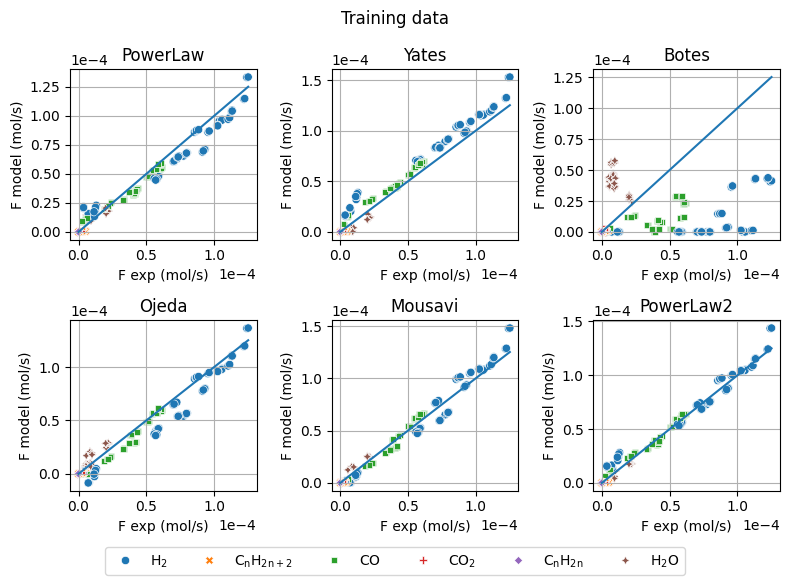

In [66]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation.Fout_exp.max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = data_for_simulation.loc[data_for_simulation['index'].isin(idx_training)], 
                    x = 'Fout_exp', y = f'Fout_{model}',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel('F model (mol/s)')
    flat_axs[i].set_xlabel('F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Training data')
plt.tight_layout()
fig_name = 'Fout_parity_training.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

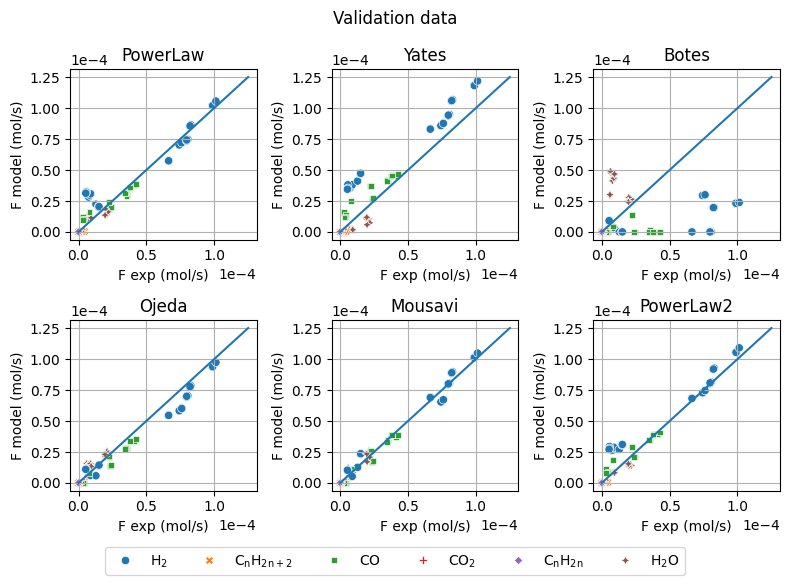

In [67]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation.Fout_exp.max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = data_for_simulation.loc[data_for_simulation['index'].isin(idx_validation)], 
                    x = 'Fout_exp', y = f'Fout_{model}',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel('F model (mol/s)')
    flat_axs[i].set_xlabel('F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Validation data')
plt.tight_layout()
fig_name = 'Fout_parity_validation.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

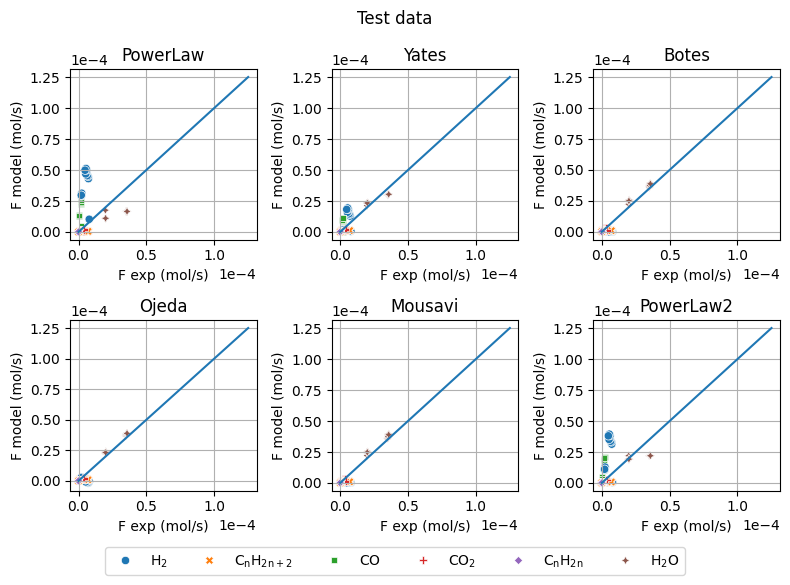

In [68]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation.Fout_exp.max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = data_for_simulation.loc[data_for_simulation['index'].isin(idx_test)], 
                    x = 'Fout_exp', y = f'Fout_{model}',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel('F model (mol/s)')
    flat_axs[i].set_xlabel('F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Test data')
plt.tight_layout()
fig_name = 'Fout_parity_test.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

In [69]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 '$\\mathrm{CH_4}$':          16,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{CO_2}$':          44,
 '$\\mathrm{C_2 H_4}$':        2*12 + 4,
 '$\\mathrm{C_2 H_6}$':        2*12 + 6,
 '$\\mathrm{C_3 H_8}$':        3*12 + 8,
 '$\\mathrm{H_2 O}$':         18,
 '$\\mathrm{C_9 H_{20}}$':     9*12 + 20,
 '$\\mathrm{C_{10} H_{22}}$': 10*12 + 22,
 '$\\mathrm{C_{11} H_{24}}$': 11*12 + 24,
 '$\\mathrm{C_{12} H_{26}}$': 12*12 + 26,
 '$\\mathrm{C_{13} H_{28}}$': 13*12 + 28,
 '$\\mathrm{C_{14} H_{30}}$': 14*12 + 30,
 '$\\mathrm{C_{15} H_{32}}$': 15*12 + 32,
 '$\\mathrm{C_{16} H_{34}}$': 16*12 + 34,
 '$\\mathrm{C_{17} H_{36}}$': 17*12 + 36,
 '$\\mathrm{C_{18} H_{38}}$': 18*12 + 38,
 '$\\mathrm{C_{19} H_{40}}$': 19*12 + 40,
 '$\\mathrm{C_{20} H_{42}}$': 20*12 + 42,
 '$\\mathrm{C_{21} H_{44}}$': 21*12 + 44,
 '$\\mathrm{C_{22} H_{46}}$': 22*12 + 46,
 '$\\mathrm{C_{23} H_{48}}$': 23*12 + 48,
 '$\\mathrm{C_{24} H_{50}}$': 24*12 + 50,
 '$\\mathrm{C_{25} H_{52}}$': 25*12 + 52,
 '$\\mathrm{C_{26} H_{54}}$': 26*12 + 54,
 '$\\mathrm{C_{27} H_{56}}$': 27*12 + 56,
 '$\\mathrm{C_{28} H_{58}}$': 28*12 + 58,
 '$\\mathrm{C_{29} H_{60}}$': 29*12 + 60,
 '$\\mathrm{C_{30} H_{62}}$': 30*12 + 62,
 '$\\mathrm{C_9 H_{18}}$':     9*12 + 18,
 '$\\mathrm{C_{10} H_{20}}$': 10*12 + 20,
 '$\\mathrm{C_{11} H_{22}}$': 11*12 + 22,
 '$\\mathrm{C_{12} H_{24}}$': 12*12 + 24,
 '$\\mathrm{C_{13} H_{26}}$': 13*12 + 26,
 '$\\mathrm{C_{14} H_{28}}$': 14*12 + 28,
 '$\\mathrm{C_{15} H_{30}}$': 15*12 + 30,
 '$\\mathrm{C_{16} H_{32}}$': 16*12 + 32,
 '$\\mathrm{C_{17} H_{34}}$': 17*12 + 34,
 '$\\mathrm{C_{18} H_{36}}$': 18*12 + 36}

In [70]:
data_for_simulation['MM (g/mol)'] = data_for_simulation.component.map(molar_mass_dict)

In [71]:
data_for_simulation['m_out_exp (g/d)'] = 86400 * data_for_simulation['MM (g/mol)']*data_for_simulation.Fout_exp

In [72]:
for model in model_names:
    data_for_simulation[f'm_out_{model} (g/d)'] = (
        data_for_simulation['MM (g/mol)']*data_for_simulation[f'Fout_{model}']
    ) * 86400

In [73]:
plot_mass_flows = data_for_simulation.groupby(['index', 'leg_labels']).sum()

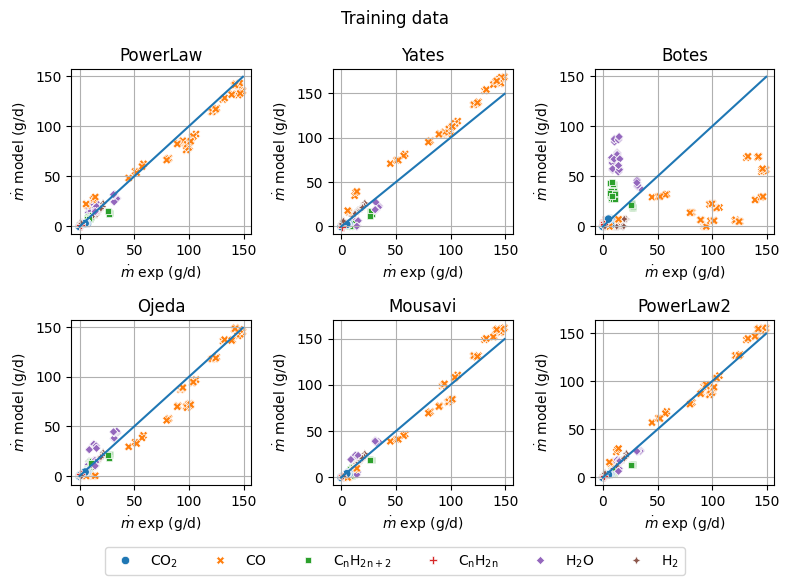

In [74]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = plot_mass_flows.loc[idx_training,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model (g/d)')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp (g/d)')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Training data')
plt.tight_layout()
fig_name = 'm_out_parity_training.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

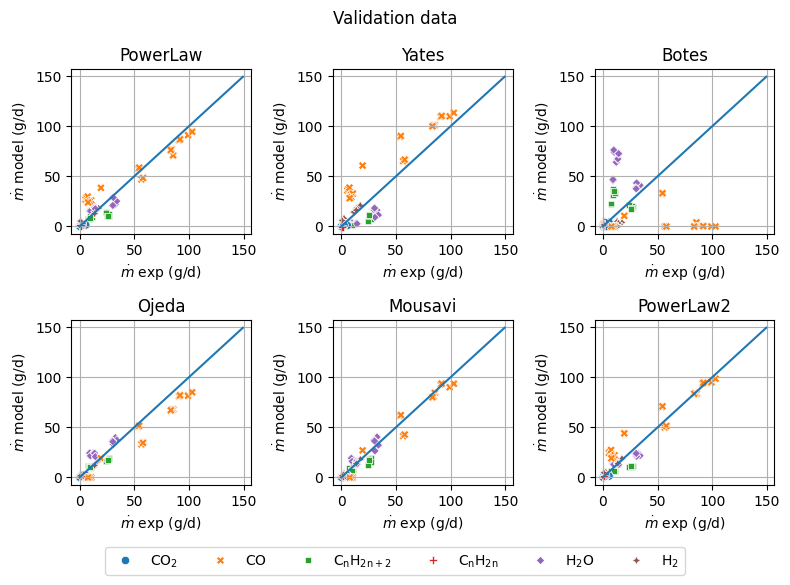

In [75]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = plot_mass_flows.loc[idx_validation,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model (g/d)')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp (g/d)')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Validation data')
plt.tight_layout()
fig_name = 'm_out_parity_validation.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

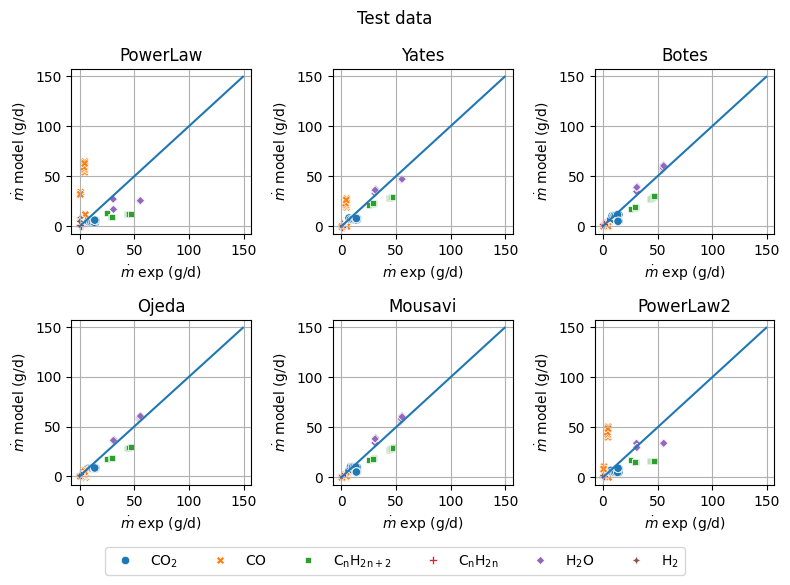

In [76]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = plot_mass_flows.loc[idx_test,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model (g/d)')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp (g/d)')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Test data')
plt.tight_layout()
fig_name = 'm_out_parity_test.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

In [77]:
results_simulation = {'model': [], 
                      'SQR_train': [], 'SQR_val': [], 'SQR_test': [], 
                      'aic_train': [], 'aic_val': [], 'aic_test': []}
for model in model_names:
    res_train = (
        plot_mass_flows.loc[idx_training, 'm_out_exp (g/d)'] -
        plot_mass_flows.loc[idx_training, f'm_out_{model} (g/d)']
    )
    res_val = (
        plot_mass_flows.loc[idx_validation, 'm_out_exp (g/d)'] -
        plot_mass_flows.loc[idx_validation, f'm_out_{model} (g/d)']
    )

    res_test = (
        plot_mass_flows.loc[idx_test, 'm_out_exp (g/d)'] -
        plot_mass_flows.loc[idx_test, f'm_out_{model} (g/d)']
    )
    
    SQR_train = res_train.pow(2).sum()
    SQR_val = res_val.pow(2).sum()
    SQR_test = res_test.pow(2).sum()

    K = len(params_dict[model])
    aic_train = 2 * K - 2 * norm.logpdf(res_train, res_train.mean(), res_train.std()).sum()
    aic_val = 2 * K - 2 * norm.logpdf(res_val, res_val.mean(), res_val.std()).sum()
    aic_test = 2 * K - 2 * norm.logpdf(res_test, res_test.mean(), res_test.std()).sum()
    
    results_simulation['model'].append(model)
    results_simulation['SQR_train'].append(SQR_train)
    results_simulation['SQR_val'].append(SQR_val)
    results_simulation['SQR_test'].append(SQR_val)
    results_simulation['aic_train'].append(aic_train)
    results_simulation['aic_val'].append(aic_val)
    results_simulation['aic_test'].append(aic_test)

In [78]:
results_simulation = pd.DataFrame(results_simulation)

In [79]:
results_simulation.sort_values('aic_val')

,model,SQR_train,SQR_val,SQR_test,aic_train,aic_val,aic_test
4,Mousavi,14344.463168,3825.695098,3825.695098,2360.401630,952.389398,523.998776
5,PowerLaw2,8165.127154,6677.421853,6677.421853,2162.306855,1049.139564,694.905753
0,PowerLaw,14148.499409,7601.022727,7601.022727,2353.288728,1062.951490,738.002975
3,Ojeda,21697.000760,8926.171687,8926.171687,2511.999980,1090.476414,525.871809
1,Yates,28208.533588,21564.319458,21564.319458,2607.600630,1227.599648,580.412705
2,Botes,630190.733427,168293.738970,168293.738970,3724.709336,1547.455628,524.996481


In [80]:
print(results_simulation[['model', 'aic_train', 'aic_val', 'aic_test']].sort_values('aic_val').to_latex(index=False, 
                                  formatters = {
                                                'aic_train': "{:.0f}",
                                                'aic_val': "{:.0f}",
                                                'aic_test': "{:.0f}",
                                               }
                                 ))

\begin{tabular}{lrrr}
\toprule
model & aic_train & aic_val & aic_test \\
\midrule
Mousavi & 2360 & 952 & 524 \\
PowerLaw2 & 2162 & 1049 & 695 \\
PowerLaw & 2353 & 1063 & 738 \\
Ojeda & 2512 & 1090 & 526 \\
Yates & 2608 & 1228 & 580 \\
Botes & 3725 & 1547 & 525 \\
\bottomrule
\end{tabular}



In [81]:
print(Mousavi_median_IQR.to_latex(index=True, 
                                  formatters = {
                                                'k_ads': lambda x: f"\\num{{{x:.3E}}}",
                                                'H_ads': lambda x: f"\\num{{{x:.1f}}}",
                                                'A_HCs': lambda x: f"\\num{{{x:.3E}}}",
                                                'E_HCs': lambda x: f"\\num{{{x:.0f}}}"
                                            }
                                 ))
# units
# k_ads = 1 / Pa
# H_ads = J / mol
# A_HCs = mol / s / g / Pa^1.75
# E_HCs = J / mol

\begin{tabular}{lrrrr}
\toprule
 & k_ads & H_ads & A_HCs & E_HCs \\
\midrule
1st quartile & \num{6.198E-06} & \num{-2878.8} & \num{1.222E-03} & \num{110392} \\
median & \num{1.398E-05} & \num{933.0} & \num{9.551E-01} & \num{147204} \\
3rd quartile & \num{3.689E-05} & \num{3711.7} & \num{1.218E+02} & \num{170946} \\
\bottomrule
\end{tabular}



In [82]:
Mousavi_median_IQR

,k_ads,H_ads,A_HCs,E_HCs
1st quartile,0.000006,-2878.819668,0.001222,110392.462543
median,0.000014,932.979072,0.955061,147203.925984
3rd quartile,0.000037,3711.699128,121.830552,170946.314555


In [83]:
dict(Mousavi_median_IQR.loc['median'])

{'k_ads': np.float64(1.397972209918762e-05),
 'H_ads': np.float64(932.9790718460237),
 'A_HCs': np.float64(0.9550608601894232),
 'E_HCs': np.float64(147203.9259840268)}

In [84]:
Mousavi_param_dict

{'k_ads': np.float64(1.397972209918762e-05),
 'H_ads': np.float64(932.9790718460237),
 'A_HCs': np.float64(955.0608601894231),
 'E_HCs': np.float64(147203.9259840268),
 'A_WGS': np.float64(2066275395.2988818),
 'E_WGS': np.float64(164536.37699675243),
 'a_WGS': np.float64(0.016649380568140318),
 'b_WGS': np.float64(0.5269130869163346)}